# Tree visualization and clinical interpretability
---
Decision Tree Methods for Clinical Heart Disease Classification. A comparison study of unpruned CART, pruned CART and conditional inference tree classification.


In [2]:
# Loads
from citrees import ConditionalInferenceTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from joblib import Parallel, delayed

In [3]:
# Config
seed = random.seed(42)
cv_folds = 5

## Data load

In [ ]:
url = "https://archive.ics.uci.edu/static/public/275/data.csv"
df = pd.read_csv(url)


y = df['cnt']


cols_to_drop = ['instant', 'dteday', 'cnt']
X = df.drop(columns=cols_to_drop)

print("--- Features (X) ---")
print(X.head())
print("\n--- Target (y) ---")
print(y.head())

--- Features (X) ---
   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  casual  registered  
0  0.2879  0.81        0.0       3          13  
1  0.2727  0.80        0.0       8          32  
2  0.2727  0.80        0.0       5          27  
3  0.2879  0.75        0.0       3          10  
4  0.2879  0.75        0.0       0           1  

--- Target (y) ---
0    16
1    40
2    32
3    13
4     1
Name: Decision, dtype: int64


## Unpruned CART

Tree Depth: 21
Total Leaves: 8725
Scores for each fold: [0.99917071 0.9990856  0.99944997 0.99727073 0.99769819]
Mean CV Accuracy: 0.9985
|--- registered <= 200.50
|   |--- registered <= 84.50
|   |   |--- registered <= 37.50
|   |   |   |--- registered <= 15.50
|   |   |   |   |--- registered <= 7.50
|   |   |   |   |   |--- registered <= 3.50
|   |   |   |   |   |   |--- casual <= 1.50
|   |   |   |   |   |   |   |--- registered <= 2.50
|   |   |   |   |   |   |   |   |--- registered <= 1.50
|   |   |   |   |   |   |   |   |   |--- casual <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |   |   |   |   |   |--- casual >  0.50
|   |   |   |   |   |   |   |   |   |   |--- registered <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |   |   |   |   |   |   |--- registered >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [2.00]
|   |   |   |   |   |   |   |   |--- registered >  1.50
|   |   |   |   |   

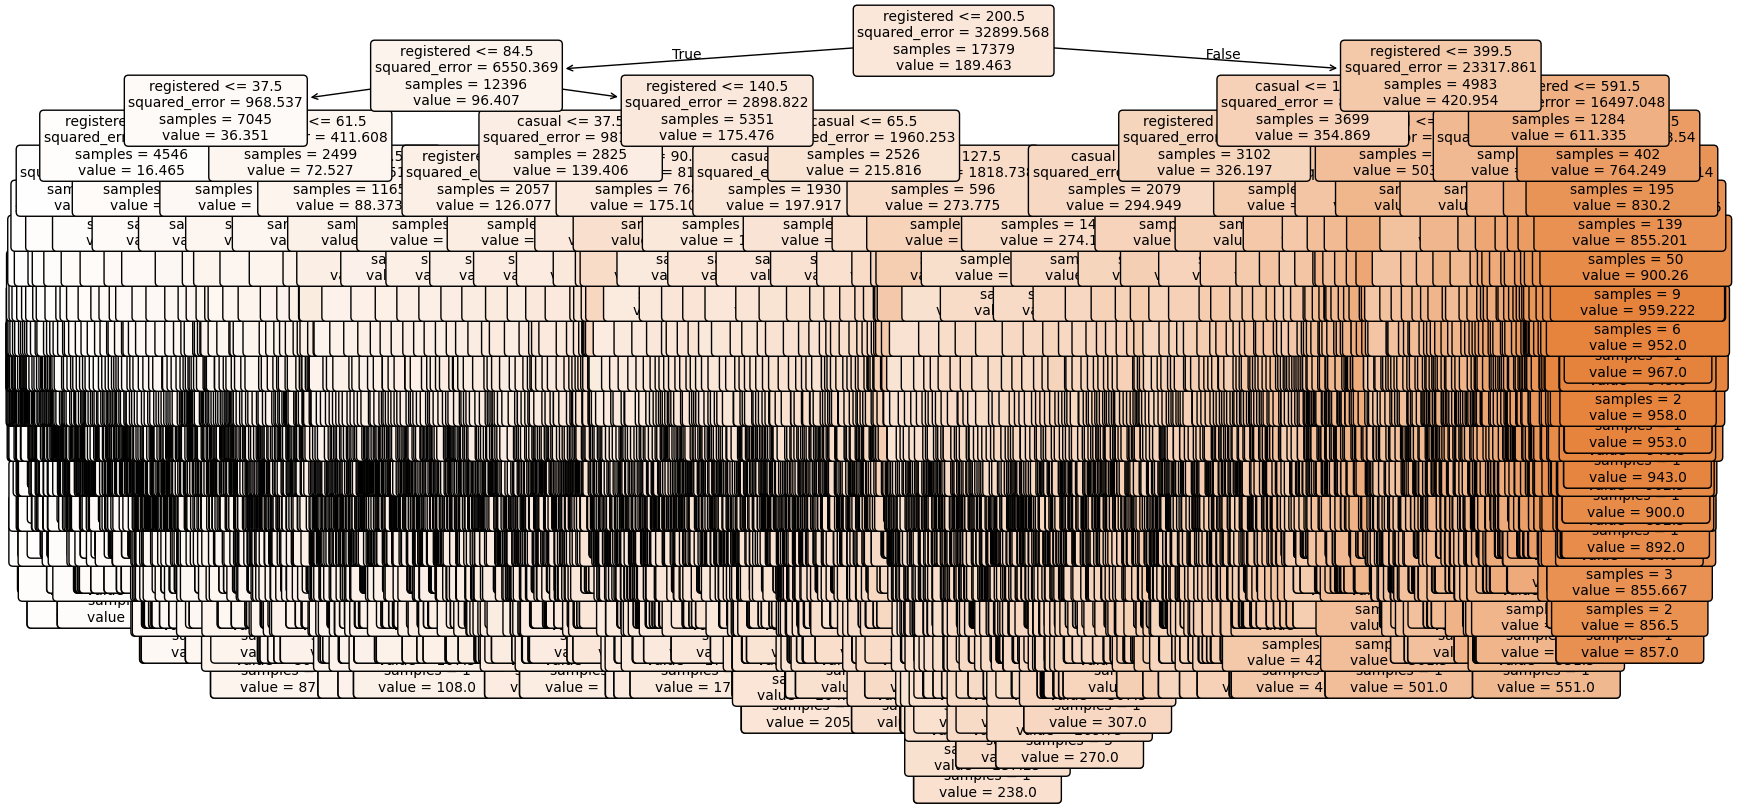

In [8]:
# Create Decision Tree Regressor
tree_regressor = DecisionTreeRegressor(random_state=seed)

# 1. Fit on full dataset to inspect tree structure
tree_regressor.fit(X, y)

depth = tree_regressor.get_depth()
num_leaves = tree_regressor.get_n_leaves()
print(f"Tree Depth: {depth}")
print(f"Total Leaves: {num_leaves}")

# 2. Separately run 5-fold CV (fits its own internal copies of the model)
cv_scores = cross_val_score(tree_regressor, X, y, cv=cv_folds)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

tree_rules = export_text(tree_regressor, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(20, 10))
plot_tree(tree_regressor, 
          feature_names=list(X.columns), 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

## Pruned CARTs 

Total alphas to evaluate: 8476


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

Best alpha: 0.0007, Best CV R²: 0.9988
Tree Depth: 16
Total Leaves: 3066
Scores for each fold: [0.9991842  0.99917235 0.99945746 0.99759483 0.99804749]
Mean CV R²: 0.9987
|--- registered <= 200.50
|   |--- registered <= 84.50
|   |   |--- registered <= 37.50
|   |   |   |--- registered <= 15.50
|   |   |   |   |--- registered <= 7.50
|   |   |   |   |   |--- registered <= 3.50
|   |   |   |   |   |   |--- casual <= 1.50
|   |   |   |   |   |   |   |--- registered <= 2.50
|   |   |   |   |   |   |   |   |--- registered <= 1.50
|   |   |   |   |   |   |   |   |   |--- casual <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |   |   |   |   |   |--- casual >  0.50
|   |   |   |   |   |   |   |   |   |   |--- registered <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |   |   |   |   |   |   |--- registered >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [2.00]
|   |   |   |   |   |   |   |   |--- regist

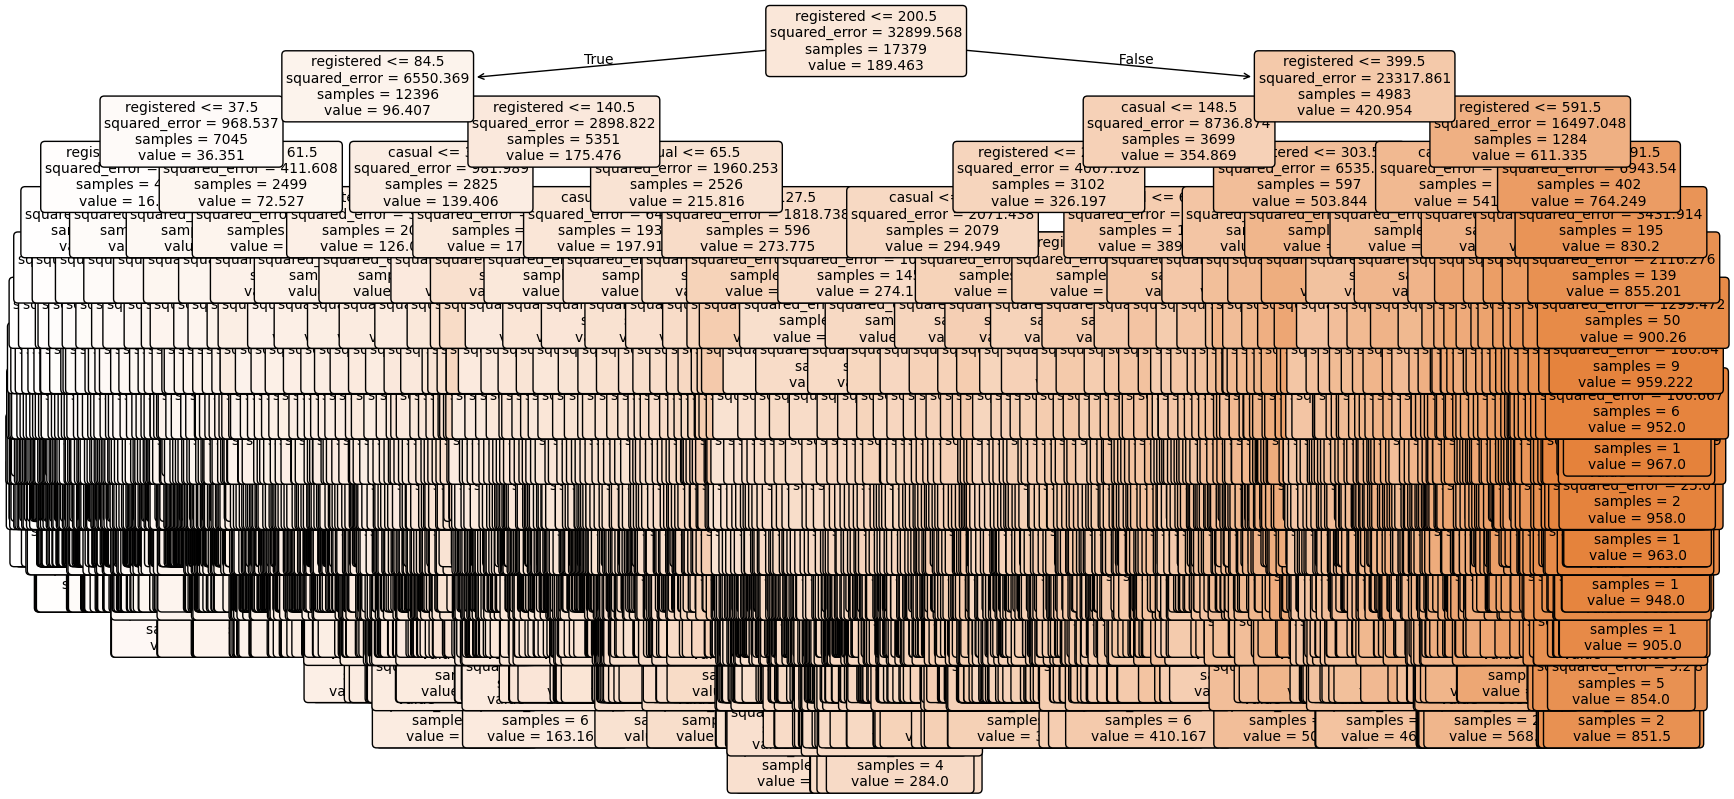

In [10]:
path = tree_regressor.cost_complexity_pruning_path(X, y)
alphas = path.ccp_alphas
print(f"Total alphas to evaluate: {len(alphas)}")

def evaluate_alpha(alpha, X, y, cv_folds, seed):
    dt = DecisionTreeRegressor(ccp_alpha=alpha, random_state=seed)
    # n_jobs=-1 parallelises the CV folds too
    scores = cross_val_score(dt, X, y, cv=cv_folds, n_jobs=-1)
    return alpha, scores.mean()

# Parallelise across all alphas using all available CPU cores
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(evaluate_alpha)(alpha, X, y, cv_folds, seed)
    for alpha in alphas
)

# Find best alpha from results
best_alpha, best_score = max(results, key=lambda x: x[1])
print(f"Best alpha: {best_alpha:.4f}, Best CV R²: {best_score:.4f}")

# Refit pruned tree
pruned_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=seed)
pruned_tree.fit(X, y)

depth = pruned_tree.get_depth()
num_leaves = pruned_tree.get_n_leaves()
print(f"Tree Depth: {depth}")
print(f"Total Leaves: {num_leaves}")

cv_scores = cross_val_score(pruned_tree, X, y, cv=cv_folds, n_jobs=-1)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

tree_rules = export_text(pruned_tree, feature_names=list(X.columns))
print(tree_rules)

plt.figure(figsize=(20, 10))
plot_tree(pruned_tree,
          feature_names=list(X.columns),
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

## Conditional inference tree
NO VA

In [27]:
clf = ConditionalInferenceTreeClassifier(
    selector="mc",
    splitter="gini",
    alpha_selector=0.05,  
    alpha_splitter=0.05,  
    random_state=seed
)
clf.fit(X, y)

,selector,'mc'
,splitter,'gini'
,alpha_selector,0.05
,alpha_splitter,0.05
,adjust_alpha_selector,True
,adjust_alpha_splitter,True
,n_resamples_selector,'auto'
,n_resamples_splitter,'auto'
,early_stopping_selector,'adaptive'
,early_stopping_splitter,'adaptive'
,early_stopping_confidence_selector,0.95


In [28]:
cv_scores = cross_val_score(clf, X, y, cv=cv_folds, n_jobs=-1)
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

/home/ariadna/Documentos/Master/ADM/my_env/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Scores for each fold: [0.29027618 0.26812428 0.29746835 0.29401611 0.30388489]
Mean CV R²: 0.2908
